In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# CHALLENGE 2 - MEASUREMENT DRIFT

FILE_PATH = "../data/surprise_challenge_2.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully
Shape: (1800, 8)


,Station_ID,Timestamp,CO_Channel,NOx_Channel,NO2_Channel,Ambient_Temperature,Relative_Humidity,Absolute_Humidity
0,SC2-01,2022-10-01 00:00:00,2.7,291.0,137.0,18.4,72.9,1.4813
1,SC2-01,2022-10-01 01:00:00,2.5,285.0,130.0,17.0,72.3,1.3992
2,SC2-01,2022-10-01 02:00:00,2.6,261.0,110.0,14.8,74.3,1.3481
3,SC2-01,2022-10-01 03:00:00,2.1,275.0,103.0,14.5,74.1,1.3101
4,SC2-01,2022-10-01 04:00:00,1.2,NaN,58.0,14.0,79.1,1.3246


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nNumber of stations:")
print(df["Station_ID"].nunique())

print("\nStations:")
print(df["Station_ID"].unique())

Columns:
['Station_ID', 'Timestamp', 'CO_Channel', 'NOx_Channel', 'NO2_Channel', 'Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity']

Data types:
Station_ID                 str
Timestamp                  str
CO_Channel             float64
NOx_Channel            float64
NO2_Channel            float64
Ambient_Temperature    float64
Relative_Humidity      float64
Absolute_Humidity      float64
dtype: object

Missing values:


Station_ID              0
Timestamp               0
CO_Channel             44
NOx_Channel            54
NO2_Channel            54
Ambient_Temperature    28
Relative_Humidity      36
Absolute_Humidity      36
dtype: int64


Number of stations:
2

Stations:
<StringArray>
['SC2-01', 'SC2-02']
Length: 2, dtype: str


In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df = df.sort_values(
    ["Station_ID", "Timestamp"]
).reset_index(drop=True)

print("Time range:")
print(df["Timestamp"].min(), "to", df["Timestamp"].max())

display(df.head())

Time range:
2022-10-01 00:00:00 to 2022-11-07 11:00:00


,Station_ID,Timestamp,CO_Channel,NOx_Channel,NO2_Channel,Ambient_Temperature,Relative_Humidity,Absolute_Humidity
0,SC2-01,2022-10-01 00:00:00,2.7,291.0,137.0,18.4,72.9,1.4813
1,SC2-01,2022-10-01 01:00:00,2.5,285.0,130.0,17.0,72.3,1.3992
2,SC2-01,2022-10-01 02:00:00,2.6,261.0,110.0,14.8,74.3,1.3481
3,SC2-01,2022-10-01 03:00:00,2.1,275.0,103.0,14.5,74.1,1.3101
4,SC2-01,2022-10-01 04:00:00,1.2,NaN,58.0,14.0,79.1,1.3246


In [ ]:
SENSOR_COLS = [
    "CO_Channel",
    "NOx_Channel",
    "NO2_Channel"
]

CONTEXT_COLS = [
    "Ambient_Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

print("Sensor channels:")
print(SENSOR_COLS)

print("\nContext channels:")
print(CONTEXT_COLS)

Sensor channels:
['CO_Channel', 'NOx_Channel', 'NO2_Channel']

Context channels:
['Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity']


In [ ]:
display(
    df[SENSOR_COLS + CONTEXT_COLS].describe().T
)

,count,mean,std,min,25%,50%,75%,max
CO_Channel,1756.0,3.638227,2.024059,0.000000,2.100000,3.30000,4.800000,10.00000
NOx_Channel,1746.0,359.217662,201.951672,-396.133682,209.000000,352.50000,496.592835,900.00000
NO2_Channel,1746.0,89.645793,45.047787,-0.828071,59.000000,92.00000,119.000000,504.38305
Ambient_Temperature,1772.0,18.430825,5.750343,-15.000000,14.900000,18.60000,22.400000,32.80000
Relative_Humidity,1764.0,59.271485,14.362506,14.100000,49.300000,59.50000,69.800000,99.00000
Absolute_Humidity,1764.0,1.330890,0.337139,-0.582236,1.140275,1.31865,1.520150,2.23490


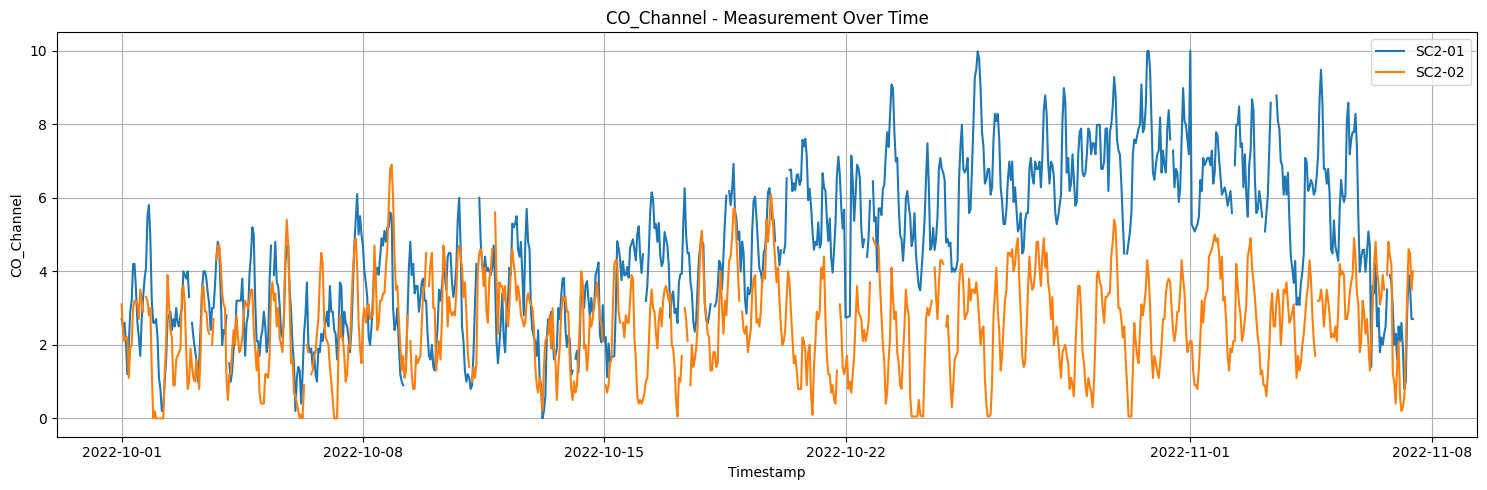

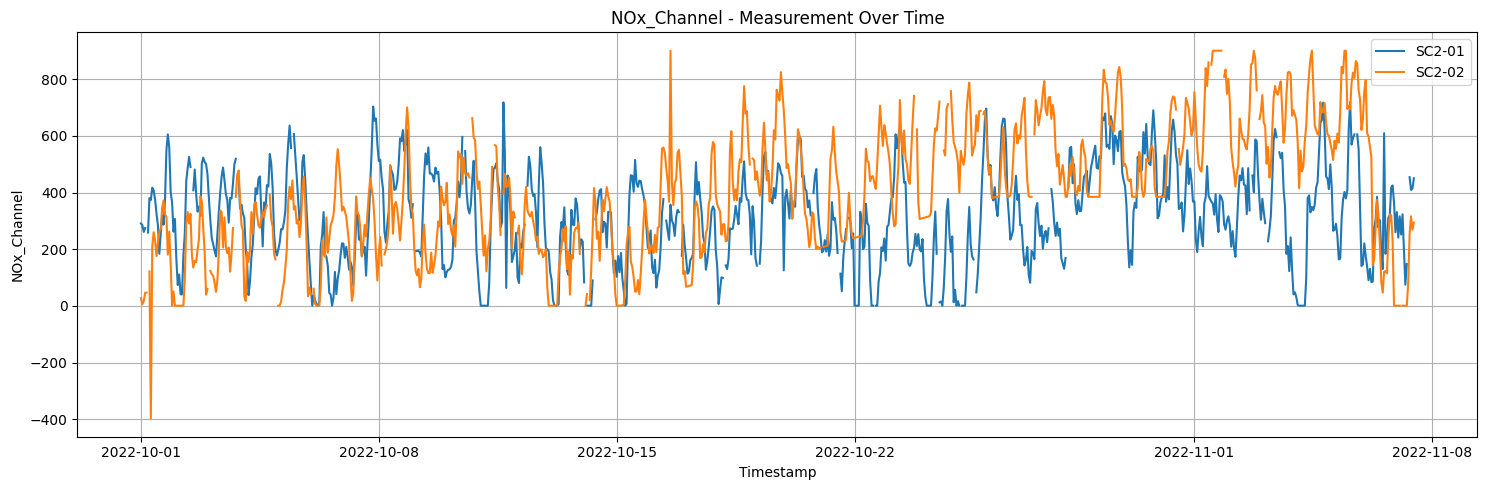

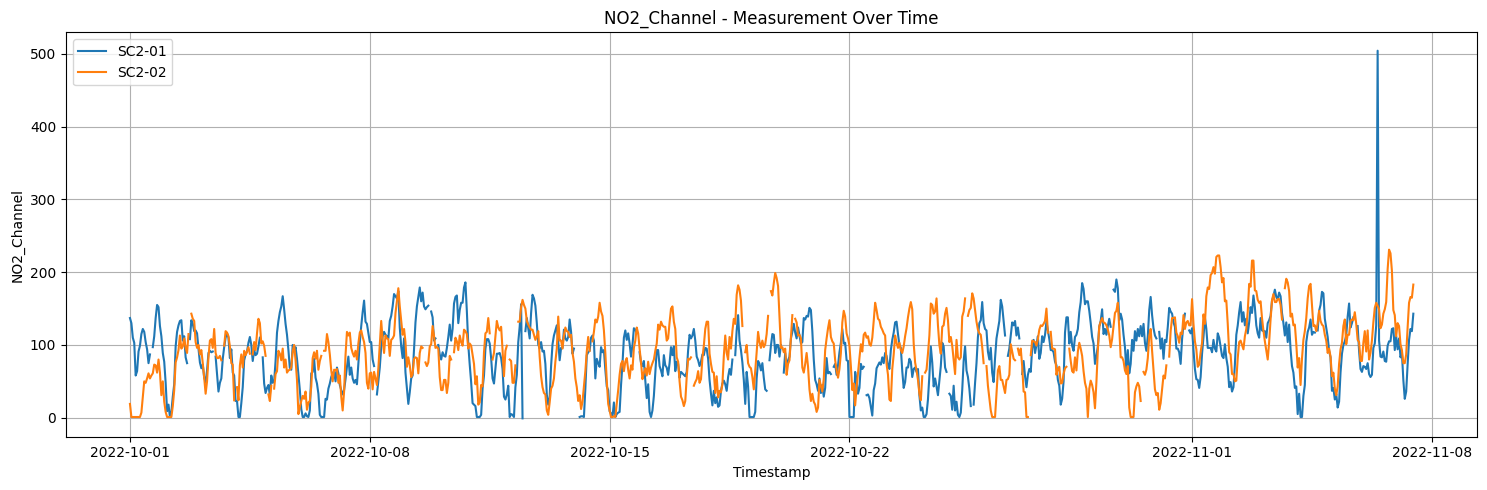

In [ ]:
for col in SENSOR_COLS:

    plt.figure(figsize=(15, 5))

    for station in df["Station_ID"].unique():

        temp = df[df["Station_ID"] == station]

        plt.plot(
            temp["Timestamp"],
            temp[col],
            label=station
        )

    plt.title(f"{col} - Measurement Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
WINDOW = 24

print("Rolling window:", WINDOW, "hours")

Rolling window: 24 hours


In [ ]:
for col in SENSOR_COLS:

    df[f"{col}_rolling_mean"] = (
        df.groupby("Station_ID")[col]
        .transform(
            lambda x: x.rolling(
                WINDOW,
                min_periods=12
            ).mean()
        )
    )

In [ ]:
def calculate_slope(values):

    values = np.asarray(values)

    valid = ~np.isnan(values)

    if valid.sum() < 10:
        return np.nan

    x = np.arange(len(values))[valid]
    y = values[valid]

    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)

    return model.coef_[0]

In [ ]:
for col in SENSOR_COLS:

    df[f"{col}_rolling_slope"] = (
        df.groupby("Station_ID")[col]
        .rolling(
            WINDOW,
            min_periods=12
        )
        .apply(
            calculate_slope,
            raw=True
        )
        .reset_index(
            level=0,
            drop=True
        )
    )

In [ ]:
EWMA_SPAN = 24

for col in SENSOR_COLS:

    df[f"{col}_ewma"] = (
        df.groupby("Station_ID")[col]
        .transform(
            lambda x: x.ewm(
                span=EWMA_SPAN,
                adjust=False
            ).mean()
        )
    )

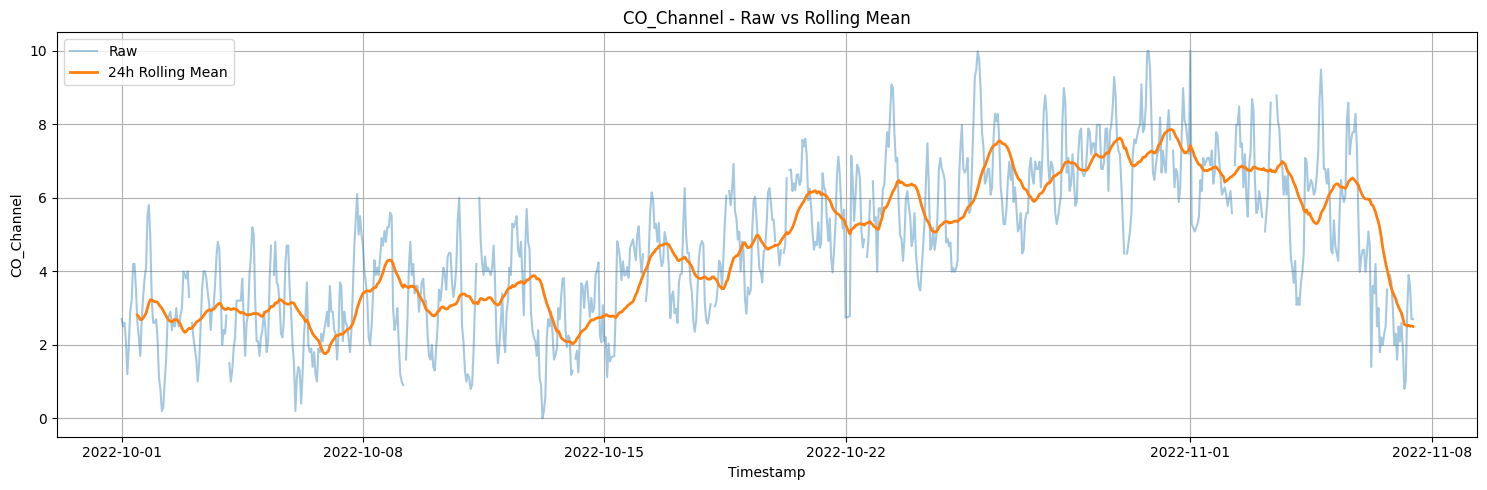

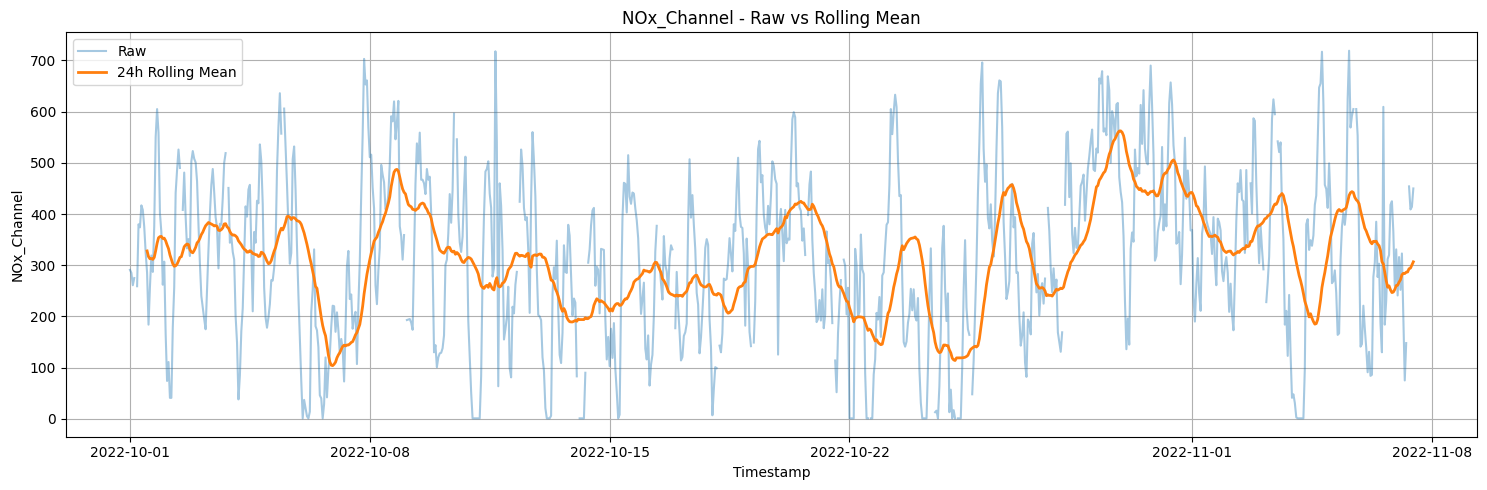

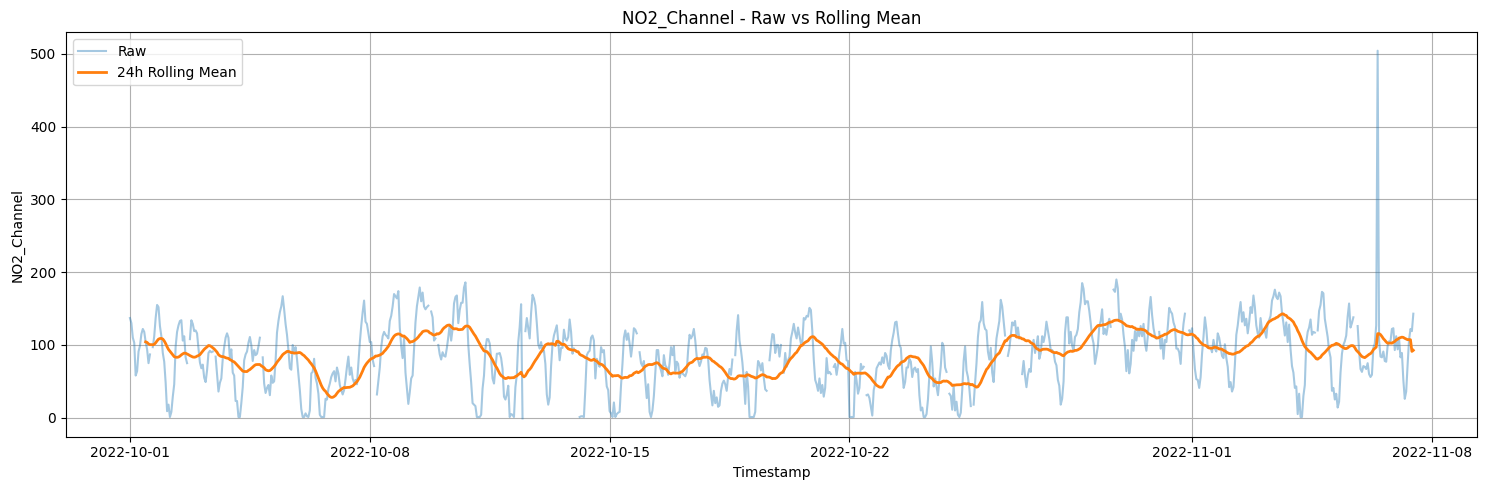

In [ ]:
for col in SENSOR_COLS:

    plt.figure(figsize=(15, 5))

    station = df["Station_ID"].iloc[0]

    temp = df[df["Station_ID"] == station]

    plt.plot(
        temp["Timestamp"],
        temp[col],
        alpha=0.4,
        label="Raw"
    )

    plt.plot(
        temp["Timestamp"],
        temp[f"{col}_rolling_mean"],
        linewidth=2,
        label="24h Rolling Mean"
    )

    plt.title(f"{col} - Raw vs Rolling Mean")
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
BASELINE_FRACTION = 0.30

baseline_stats = {}

for station in df["Station_ID"].unique():

    station_df = df[
        df["Station_ID"] == station
    ].copy()

    cutoff = int(
        len(station_df) * BASELINE_FRACTION
    )

    baseline_df = station_df.iloc[:cutoff]

    baseline_stats[station] = {}

    for col in SENSOR_COLS:

        mean_value = baseline_df[col].mean()
        std_value = baseline_df[col].std()

        baseline_stats[station][col] = {
            "mean": mean_value,
            "std": std_value
        }

print("Baseline calculated.")

Baseline calculated.


In [ ]:
for col in SENSOR_COLS:

    df[f"{col}_baseline_deviation"] = np.nan

    for station in df["Station_ID"].unique():

        mask = df["Station_ID"] == station

        baseline_mean = baseline_stats[
            station
        ][col]["mean"]

        baseline_std = baseline_stats[
            station
        ][col]["std"]

        df.loc[
            mask,
            f"{col}_baseline_deviation"
        ] = (
            df.loc[
                mask,
                f"{col}_rolling_mean"
            ] - baseline_mean
        ) / (baseline_std + 1e-8)

In [ ]:
for col in SENSOR_COLS:

    df[f"{col}_ewma_deviation"] = np.nan

    for station in df["Station_ID"].unique():

        mask = df["Station_ID"] == station

        baseline_mean = baseline_stats[
            station
        ][col]["mean"]

        baseline_std = baseline_stats[
            station
        ][col]["std"]

        df.loc[
            mask,
            f"{col}_ewma_deviation"
        ] = (
            df.loc[
                mask,
                f"{col}_ewma"
            ] - baseline_mean
        ) / (baseline_std + 1e-8)

In [ ]:
for col in SENSOR_COLS:

    df[f"{col}_slope_score"] = np.nan

    for station in df["Station_ID"].unique():

        mask = df["Station_ID"] == station

        station_df = df.loc[mask]

        baseline_length = int(
            len(station_df) * BASELINE_FRACTION
        )

        baseline_slopes = (
            station_df[
                f"{col}_rolling_slope"
            ].iloc[:baseline_length]
        )

        slope_scale = (
            baseline_slopes.std()
            + 1e-8
        )

        df.loc[
            mask,
            f"{col}_slope_score"
        ] = (
            df.loc[
                mask,
                f"{col}_rolling_slope"
            ].abs()
            / slope_scale
        )

In [ ]:
for col1, col2 in [
    ("CO_Channel", "NOx_Channel"),
    ("CO_Channel", "NO2_Channel"),
    ("NOx_Channel", "NO2_Channel")
]:

    name = f"{col1}_{col2}_corr"

    df[name] = (
        df.groupby("Station_ID")
        .apply(
            lambda group: group[col1]
            .rolling(WINDOW)
            .corr(group[col2])
        )
        .reset_index(
            level=0,
            drop=True
        )
    )

In [ ]:
def add_residual_feature(df, target, predictors):

    result = np.full(len(df), np.nan)

    for station in df["Station_ID"].unique():

        mask = (
            df["Station_ID"] == station
        )

        station_indices = np.where(mask)[0]

        station_data = df.loc[
            mask,
            [target] + predictors
        ].copy()

        valid = station_data.notna().all(axis=1)

        if valid.sum() < 50:
            continue

        X = station_data.loc[
            valid,
            predictors
        ]

        y = station_data.loc[
            valid,
            target
        ]

        model = LinearRegression()
        model.fit(X, y)

        predictions = model.predict(X)

        residuals = y.values - predictions

        residual_std = (
            np.std(residuals) + 1e-8
        )

        scores = np.abs(
            residuals / residual_std
        )

        valid_indices = station_indices[
            np.where(valid)[0]
        ]

        result[
            valid_indices
        ] = scores

    return result

In [ ]:
df["CO_relationship_score"] = add_residual_feature(
    df,
    "CO_Channel",
    ["NOx_Channel", "NO2_Channel"]
)

df["NOx_relationship_score"] = add_residual_feature(
    df,
    "NOx_Channel",
    ["CO_Channel", "NO2_Channel"]
)

df["NO2_relationship_score"] = add_residual_feature(
    df,
    "NO2_Channel",
    ["CO_Channel", "NOx_Channel"]
)

In [ ]:
for col in SENSOR_COLS:

    relationship_col = (
        col.replace(
            "_Channel",
            "_relationship_score"
        )
    )

    df[f"{col}_drift_score"] = (
        0.35 *
        df[f"{col}_baseline_deviation"].abs()
        +
        0.25 *
        df[f"{col}_ewma_deviation"].abs()
        +
        0.25 *
        df[f"{col}_slope_score"].abs()
        +
        0.15 *
        df[relationship_col].fillna(0)
    )

In [ ]:
DRIFT_QUANTILE = 0.95

thresholds = {}

for station in df["Station_ID"].unique():

    thresholds[station] = {}

    station_df = df[
        df["Station_ID"] == station
    ]

    baseline_length = int(
        len(station_df) * BASELINE_FRACTION
    )

    baseline_df = station_df.iloc[
        :baseline_length
    ]

    for col in SENSOR_COLS:

        score_col = (
            f"{col}_drift_score"
        )

        threshold = (
            baseline_df[score_col]
            .dropna()
            .quantile(DRIFT_QUANTILE)
        )

        thresholds[station][col] = threshold

thresholds

{'SC2-01': {'CO_Channel': np.float64(0.8527939466225155),
  'NOx_Channel': np.float64(0.8927087076404387),
  'NO2_Channel': np.float64(0.9841388963751264)},
 'SC2-02': {'CO_Channel': np.float64(0.9098688444251816),
  'NOx_Channel': np.float64(0.9651862261046821),
  'NO2_Channel': np.float64(1.1024898031411088)}}

In [ ]:
for col in SENSOR_COLS:

    df[f"{col}_drift_candidate"] = False

    for station in df["Station_ID"].unique():

        mask = (
            df["Station_ID"] == station
        )

        threshold = thresholds[
            station
        ][col]

        df.loc[
            mask,
            f"{col}_drift_candidate"
        ] = (
            df.loc[
                mask,
                f"{col}_drift_score"
            ] > threshold
        )

In [ ]:
PERSISTENCE_WINDOW = 12
for col in SENSOR_COLS:

    flag_col = (
        f"{col}_drift_candidate"
    )

    persistent_col = (
        f"{col}_persistent_drift"
    )

    df[persistent_col] = (
        df.groupby("Station_ID")[flag_col]
        .transform(
            lambda x:
            x.astype(int)
             .rolling(
                 PERSISTENCE_WINDOW,
                 min_periods=8
             )
             .mean()
             >= 0.70
        )
    )

In [ ]:
drift_results = []

for station in df["Station_ID"].unique():

    station_df = df[
        df["Station_ID"] == station
    ].copy()

    for col in SENSOR_COLS:

        flag_col = (
            f"{col}_persistent_drift"
        )

        drift_points = station_df[
            station_df[flag_col] == True
        ]

        if len(drift_points) > 0:

            first_point = drift_points.iloc[0]

            start_time = first_point["Timestamp"]

            confidence = min(
                first_point[
                    f"{col}_drift_score"
                ]
                /
                (
                    thresholds[
                        station
                    ][col] + 1e-8
                ),
                1.0
            )

            drift_detected = True

        else:

            start_time = None
            confidence = 0
            drift_detected = False

        drift_results.append({

            "Station_ID": station,
            "Channel": col,
            "Drift_Detected": drift_detected,
            "Approx_Drift_Start": start_time,
            "Confidence": round(
                confidence,
                3
            )

        })

drift_report = pd.DataFrame(
    drift_results
)

display(drift_report)

,Station_ID,Channel,Drift_Detected,Approx_Drift_Start,Confidence
0,SC2-01,CO_Channel,True,2022-10-13 15:00:00,1.0
1,SC2-01,NOx_Channel,True,2022-10-24 13:00:00,1.0
2,SC2-01,NO2_Channel,False,NaT,0.0
3,SC2-02,CO_Channel,False,NaT,0.0
4,SC2-02,NOx_Channel,True,2022-10-19 03:00:00,1.0
5,SC2-02,NO2_Channel,True,2022-10-01 19:00:00,1.0


In [ ]:
channel_summary = []

for station in df["Station_ID"].unique():

    station_df = df[
        df["Station_ID"] == station
    ]

    for col in SENSOR_COLS:

        score_col = (
            f"{col}_drift_score"
        )

        persistent_col = (
            f"{col}_persistent_drift"
        )

        max_score = (
            station_df[score_col]
            .max()
        )

        persistence = (
            station_df[persistent_col]
            .mean()
        )

        channel_summary.append({

            "Station_ID": station,
            "Channel": col,
            "Maximum_Drift_Score": round(
                max_score, 3
            ),
            "Persistence_Rate": round(
                persistence, 3
            )

        })

channel_summary = pd.DataFrame(
    channel_summary
)

channel_summary = channel_summary.sort_values(
    "Maximum_Drift_Score",
    ascending=False
)

display(channel_summary)

,Station_ID,Channel,Maximum_Drift_Score,Persistence_Rate
0,SC2-01,CO_Channel,2.975,0.528
2,SC2-01,NO2_Channel,2.825,0.000
4,SC2-02,NOx_Channel,2.518,0.409
5,SC2-02,NO2_Channel,2.277,0.098
1,SC2-01,NOx_Channel,1.968,0.033
3,SC2-02,CO_Channel,1.432,0.000


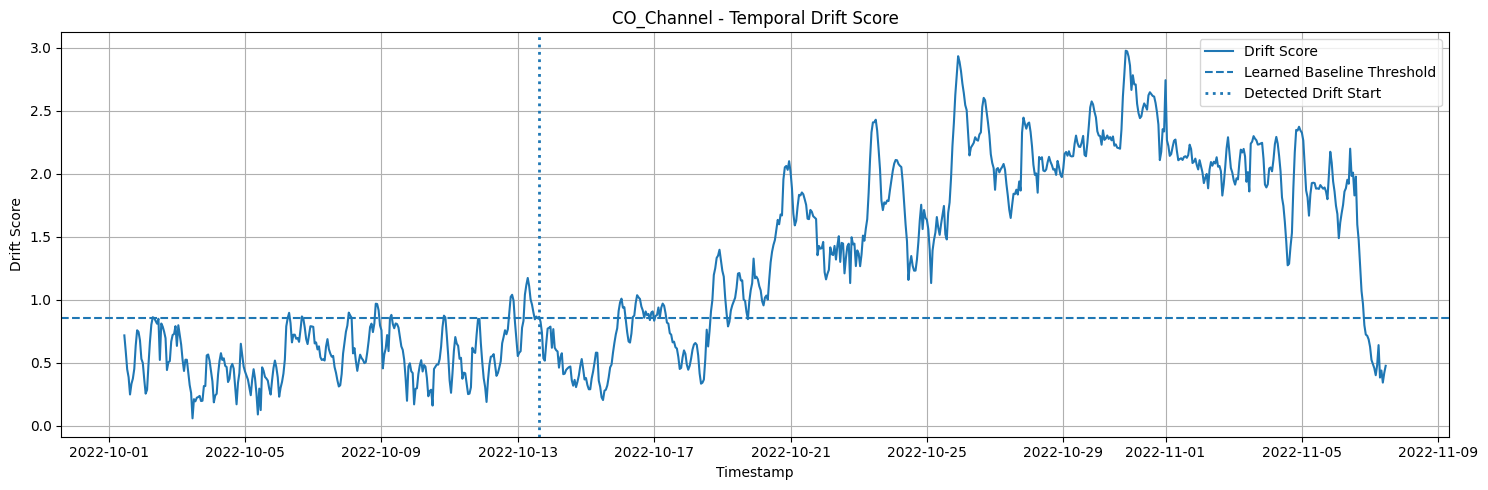

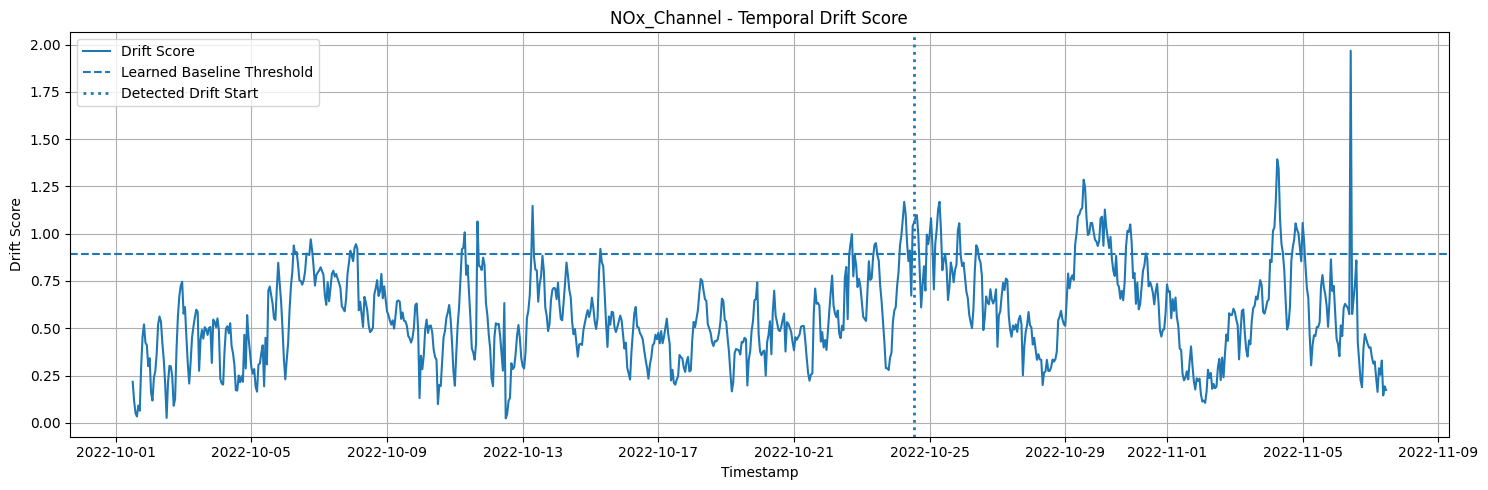

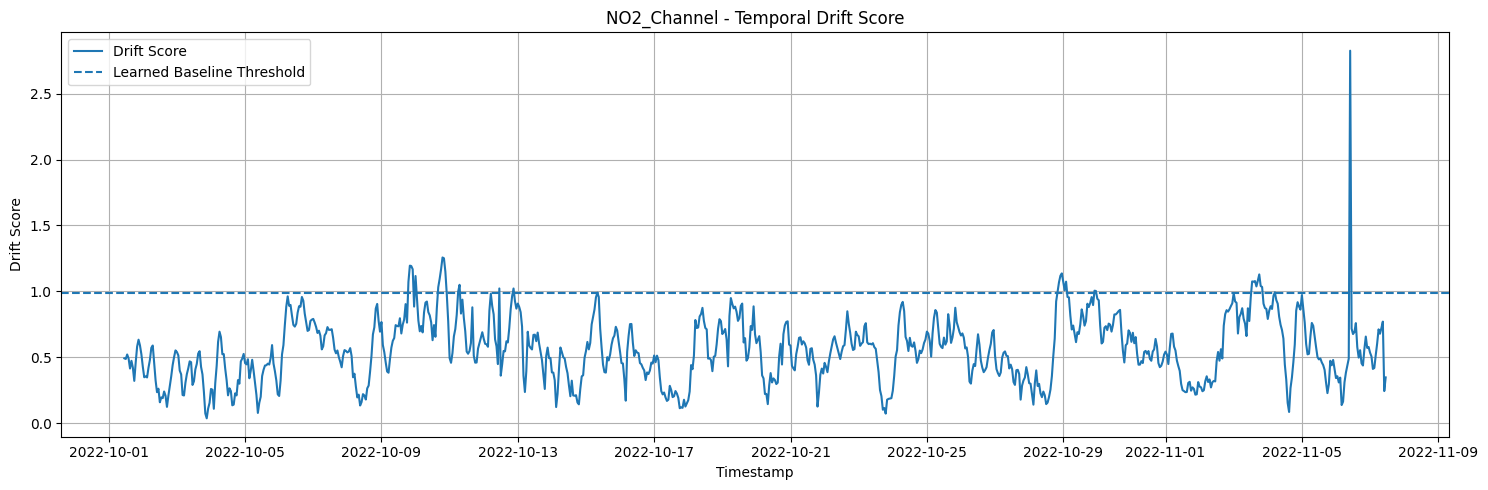

In [ ]:
for col in SENSOR_COLS:

    plt.figure(figsize=(15, 5))

    station = df["Station_ID"].iloc[0]

    temp = df[
        df["Station_ID"] == station
    ]

    plt.plot(
        temp["Timestamp"],
        temp[f"{col}_drift_score"],
        label="Drift Score"
    )

    threshold = thresholds[
        station
    ][col]

    plt.axhline(
        threshold,
        linestyle="--",
        label="Learned Baseline Threshold"
    )

    drift_mask = temp[
        f"{col}_persistent_drift"
    ]

    if drift_mask.any():

        drift_times = temp.loc[
            drift_mask,
            "Timestamp"
        ]

        plt.axvline(
            drift_times.iloc[0],
            linestyle=":",
            linewidth=2,
            label="Detected Drift Start"
        )

    plt.title(
        f"{col} - Temporal Drift Score"
    )

    plt.xlabel("Timestamp")
    plt.ylabel("Drift Score")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

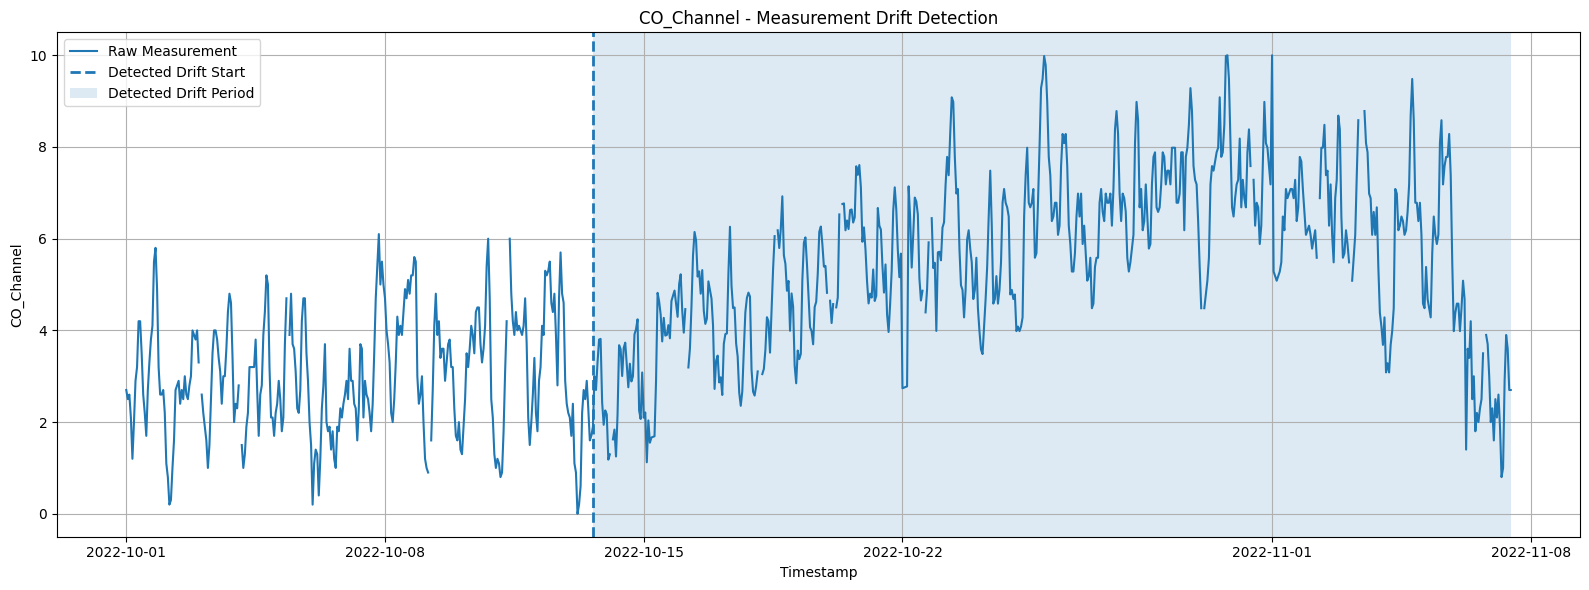

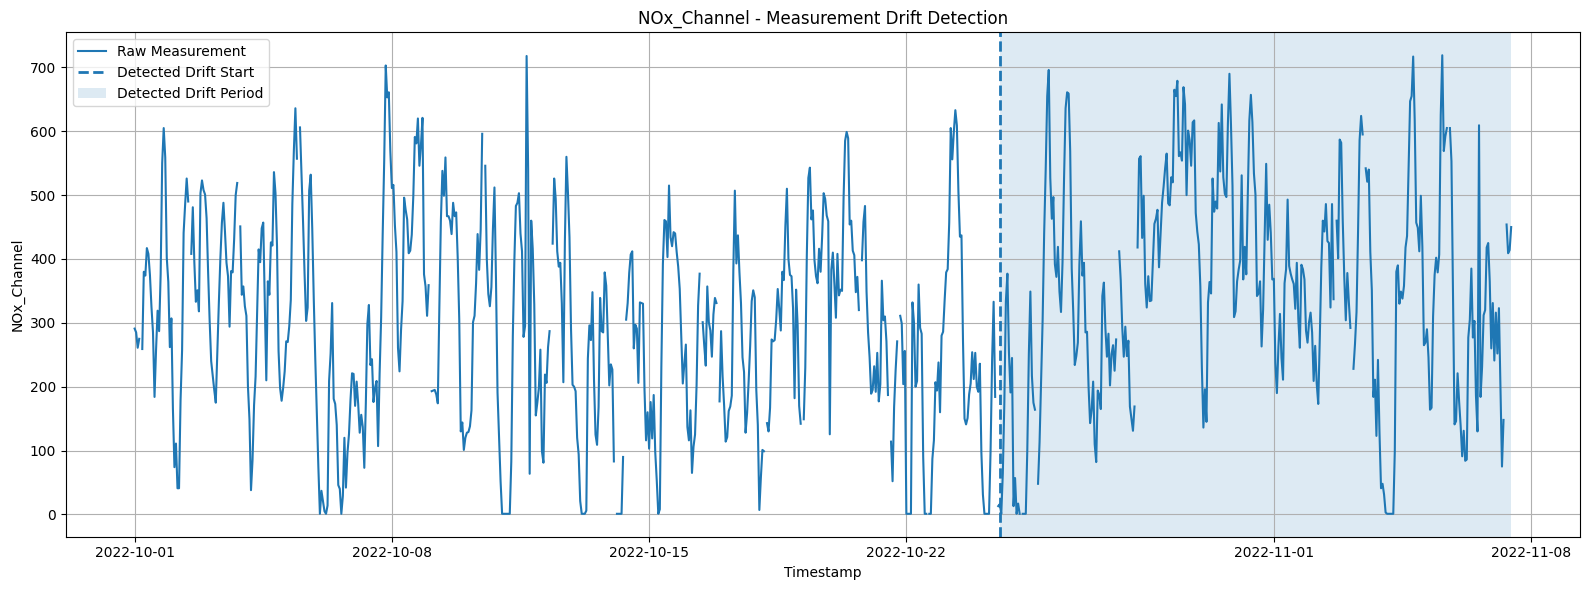

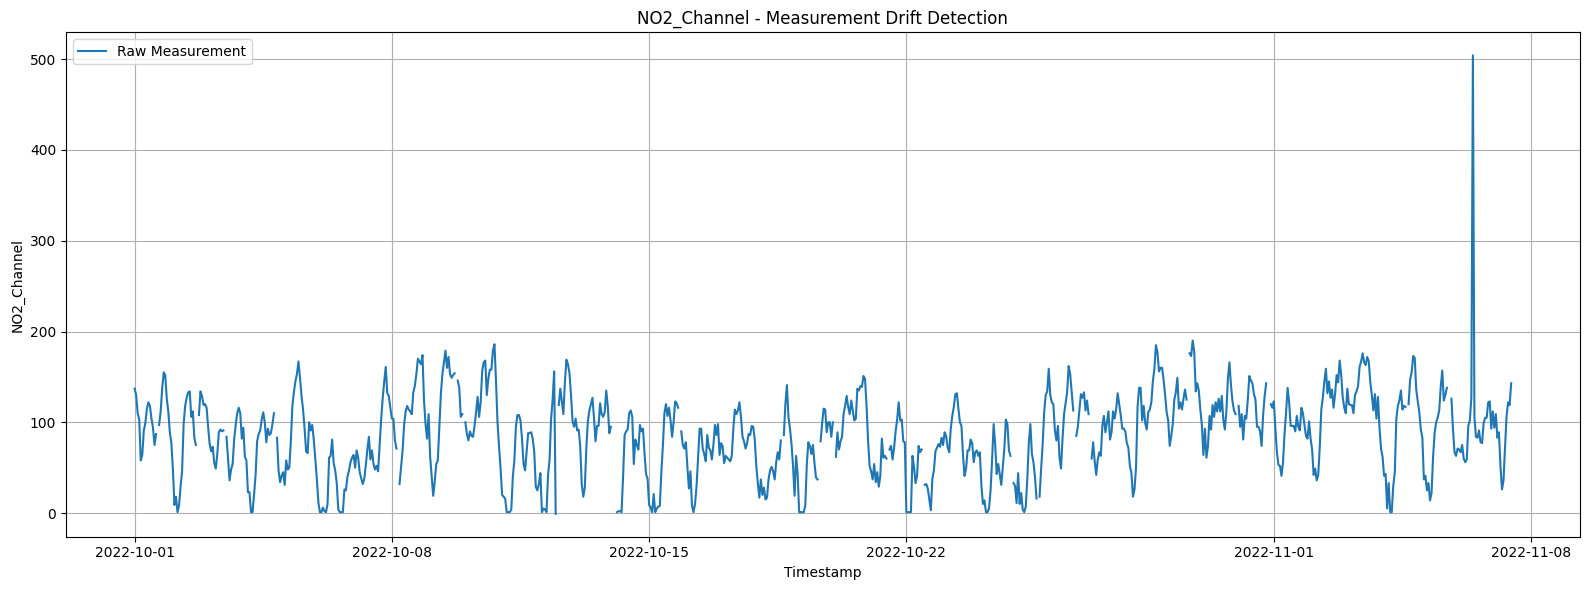

In [ ]:
for col in SENSOR_COLS:

    station = df["Station_ID"].iloc[0]

    temp = df[
        df["Station_ID"] == station
    ]

    plt.figure(figsize=(16, 6))

    plt.plot(
        temp["Timestamp"],
        temp[col],
        label="Raw Measurement"
    )

    drift_mask = temp[
        f"{col}_persistent_drift"
    ]

    if drift_mask.any():

        first_drift_time = temp.loc[
            drift_mask,
            "Timestamp"
        ].iloc[0]

        plt.axvline(
            first_drift_time,
            linestyle="--",
            linewidth=2,
            label="Detected Drift Start"
        )

        plt.axvspan(
            first_drift_time,
            temp["Timestamp"].iloc[-1],
            alpha=0.15,
            label="Detected Drift Period"
        )

    plt.title(
        f"{col} - Measurement Drift Detection"
    )

    plt.xlabel("Timestamp")
    plt.ylabel(col)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
print("=" * 70)
print("       MEASUREMENT DRIFT DETECTION REPORT")
print("=" * 70)

for station in drift_report["Station_ID"].unique():

    print(f"\nStation: {station}")
    print("-" * 70)

    station_report = drift_report[
        drift_report["Station_ID"] == station
    ]

    for _, row in station_report.iterrows():

        print(
            f"{row['Channel']:20s} | "
            f"Drift: {str(row['Drift_Detected']):5s} | "
            f"Start: {row['Approx_Drift_Start']} | "
            f"Confidence: {row['Confidence']:.2f}"
        )

print("\n" + "=" * 70)

       MEASUREMENT DRIFT DETECTION REPORT

Station: SC2-01
----------------------------------------------------------------------
CO_Channel           | Drift: True  | Start: 2022-10-13 15:00:00 | Confidence: 1.00
NOx_Channel          | Drift: True  | Start: 2022-10-24 13:00:00 | Confidence: 1.00
NO2_Channel          | Drift: False | Start: NaT | Confidence: 0.00

Station: SC2-02
----------------------------------------------------------------------
CO_Channel           | Drift: False | Start: NaT | Confidence: 0.00
NOx_Channel          | Drift: True  | Start: 2022-10-19 03:00:00 | Confidence: 1.00
NO2_Channel          | Drift: True  | Start: 2022-10-01 19:00:00 | Confidence: 1.00



In [ ]:
OUTPUT_FILE = "../data/challenge2_drift_results.csv"

drift_report.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"Drift report saved to: {OUTPUT_FILE}"
)

Drift report saved to: ../data/challenge2_drift_results.csv
